# 50 — PDB P2Rank / AFDB P2Rank / Patches: key plots

**Condensed companion to [49_p2rank_patches_pooled.ipynb](49_p2rank_patches_pooled.ipynb)**, same
format as [47_afdb_apo_holo_key_plots.ipynb](47_afdb_apo_holo_key_plots.ipynb): single square
figures, no multi-panel rows, reading the pooled+deduplicated TSVs nb49 already wrote (no
recomputation here).

Same four plot types as nb47, with **DCA in place of SC RMSD** as the structural-deviation axis —
the natural equivalent for a *predicted* pocket, where "how far is the predicted site from the true
one" (distance-based) is the standard pocket-detection accuracy metric, rather than an RMSD between
two versions of the same site. **Patches only get the score-distribution plot** — a random surface
patch isn't detecting anything, so there's no accuracy metric to correlate against, and no
best-vs-worst split to draw (nothing to rank by).

§5 additionally checks whether DCA is actually the best available metric, or whether DCC / IoU /
recall correlate with the score drop better — the "other residue metrics" question.

**Colour key** (same `42_drugclip_benchmark.ipynb` `COLOURS` dict as 37b/45/46/47): Experimental =
green, **PDB P2Rank = pink, AFDB P2Rank = red, Patches = black**. Best/worst-bin scatters use the
fixed black/red pair from nb48's exploration (not tied to condition colour, so it never clashes —
same reasoning as why nb47 stopped using each condition's own colour there).

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJ = Path.cwd().parent / 'DATA' / 'drugclip'
POOLED = PROJ / 'RESULTS/p2rank_patches_pooled'
FIG_DIR = PROJ / 'RESULTS/p2rank_patches_pooled/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_C = '#2CA02C'   # 'bound' in nb42
BEST_C   = '#000000'
WORST_C  = '#D62728'

# "Wrong" colours also come straight from nb42's COLOURS dict — it pairs each condition with its
# own wrong-prediction colour rather than one shared grey: 'pdb_wrong' (brown) for PDB P2Rank ✗,
# 'wrong_p2rank' (grey) for AFDB P2Rank ✗.
CONDITIONS = [
    {
        'key': 'pdb_p2rank', 'name': 'PDB P2Rank', 'color': '#E377C2',   # 'pdb_p2rank' in nb42
        'wrong_color': '#8C564B',   # 'pdb_wrong' in nb42 (brown)
        'path': POOLED / 'pdb_p2rank_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_pdb_p2rank', 'has_metrics': True,
    },
    {
        'key': 'afdb_p2rank', 'name': 'AFDB P2Rank', 'color': '#D62728',   # 'afdb_p2rank' in nb42
        'wrong_color': '#7F7F7F',   # 'wrong_p2rank' in nb42 (grey)
        'path': POOLED / 'afdb_p2rank_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_afdb_p2rank', 'has_metrics': True,
    },
    {
        'key': 'patches', 'name': 'Patches', 'color': '#000000',   # 'patches' in nb42
        'wrong_color': None,
        'path': POOLED / 'patches_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_patches', 'has_metrics': False,
    },
]

SCORE_LIM      = (-0.55, 0.95)
SCORE_TICKS    = np.arange(-0.4, 0.81, 0.2)
SCORE_YLIM_PCT = (0, 10)
SCORE_YTICKS_PCT = np.arange(0, 10.1, 1)
DCA_BIN_EDGES  = [0, 2.0, 4.0, 8.0, np.inf]
DCA_BIN_LABELS = ['<2', '2–4', '4–8', '>8']
DIST_LOG_LIM      = (10**-1, 10**1.5)   # shared by DCA and DCC (both Å distances)
DIST_LOG_TICKS    = [1e-1, 1e0, 1e1]
DIST_LINEAR_LIM   = (0, 10)
DIST_LINEAR_TICKS = np.arange(0, 10.1, 2)
RATIO_LIM      = (0, 1.05)           # shared by IoU and recall (bounded 0-1 ratios)
RATIO_TICKS    = np.arange(0, 1.01, 0.2)
PP_LIM         = (-0.2, 1.0)
DELTA_LIM      = (-1.2, 0.5)
DELTA_TICKS    = np.arange(-1.2, 0.41, 0.2)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                      'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12})


def square(fig):
    for ax in fig.axes:
        ax.set_box_aspect(1)
    return fig


def pct_hist(ax, vals, bins, **kwargs):
    vals = np.asarray(vals)
    weights = np.full(len(vals), 100.0 / len(vals)) if len(vals) else None
    return ax.hist(vals, bins=bins, weights=weights, **kwargs)


def save_fig(fig, name, save, dpi):
    if save:
        fig.savefig(FIG_DIR / f'{name}.png', dpi=dpi, bbox_inches='tight')

## Load

In [2]:
for c in CONDITIONS:
    df = pd.read_csv(c['path'], sep='\t')
    if c['has_metrics']:
        df['dca_bin'] = pd.cut(df['dca'], bins=DCA_BIN_EDGES, labels=DCA_BIN_LABELS, right=False)
    c['df'] = df
    print(f"{c['name']:<12s}  n={len(df):,}  ({c['path'].name})")

PDB P2Rank    n=15,328  (pdb_p2rank_vs_exp_scores_pooled_dedup.tsv)
AFDB P2Rank   n=9,831  (afdb_p2rank_vs_exp_scores_pooled_dedup.tsv)
Patches       n=15,640  (patches_vs_exp_scores_pooled_dedup.tsv)


## Plot functions

In [3]:
def plot_score_distribution(c, save=True, dpi=600):
    """Correct (DCA<=4 or DCC<=4) vs wrong predictions split out where DCA/DCC exist —
    same 'correct_either' threshold nb38/42/43 use throughout this project. Patches have
    no DCA/DCC (nothing to be "correct" about), so they stay a single series."""
    df, color, name, score_col = c['df'], c['color'], c['name'], c['score_col']
    print(f'{name}: score distribution (n={len(df):,})')
    fig, ax = plt.subplots(figsize=(6, 6))
    bins = np.linspace(*SCORE_LIM, 60)
    pct_hist(ax, df['score_exp'], bins, alpha=0.6, label='Experimental', color=SOURCE_C)
    if c['has_metrics']:
        correct = (df['dca'] <= 4) | (df['dcc'] <= 4)
        pct_hist(ax, df.loc[correct, score_col], bins, alpha=0.6, color=color,
                 label=f'{name} — correct (DCA/DCC≤4Å, n={correct.sum():,})')
        pct_hist(ax, df.loc[~correct, score_col], bins, alpha=0.6, color=c['wrong_color'],
                 label=f'{name} — wrong (n={(~correct).sum():,})')
    else:
        pct_hist(ax, df[score_col], bins, alpha=0.6, label=name, color=color)
    ax.set_xlim(SCORE_LIM); ax.set_xticks(SCORE_TICKS)
    ax.set_ylim(SCORE_YLIM_PCT); ax.set_yticks(SCORE_YTICKS_PCT)
    ax.set_xlabel('DrugCLIP cosine score')
    ax.set_ylabel('Pockets (%)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    square(fig)
    save_fig(fig, f'{c["key"]}_score_distribution', save, dpi)
    return fig


def plot_best_worst_scatter(c, save=True, dpi=600):
    df, name, score_col = c['df'], c['name'], c['score_col']
    print(f'{name}: best vs worst DCA bin (n={len(df):,} pooled)')
    fig, ax = plt.subplots(figsize=(6, 6))
    for b, col, alpha in [('<2', BEST_C, 0.15), ('>8', WORST_C, 0.5)]:
        sub = df[df['dca_bin'] == b]
        if len(sub) < 5:
            continue
        r, _ = stats.pearsonr(sub['score_exp'], sub[score_col])
        ax.scatter(sub['score_exp'], sub[score_col], s=4, alpha=alpha, color=col,
                   label=f'DCA {b} Å  Pearson r={r:.2f}  (n={len(sub):,})', rasterized=True)
    ax.plot(SCORE_LIM, SCORE_LIM, 'k--', lw=0.8, label='x = y')
    ax.set_xlim(SCORE_LIM); ax.set_ylim(SCORE_LIM)
    ax.set_xticks(SCORE_TICKS); ax.set_yticks(SCORE_TICKS)
    ax.set_xlabel('Score (experimental pocket)')
    ax.set_ylabel(f'Score ({name} pocket)')
    ax.legend(fontsize=9)
    fig.tight_layout()
    square(fig)
    save_fig(fig, f'{c["key"]}_best_worst_scatter', save, dpi)
    return fig


# Distance metrics (DCA, DCC) are Å, right-skewed -> log x-axis, shared DIST_LOG_LIM.
# Residue-overlap metrics (IoU, recall) are bounded 0-1 ratios -> linear x-axis, shared RATIO_LIM.
METRIC_INFO = {
    'dca':    {'label': 'DCA',                    'log_x': True},
    'dcc':    {'label': 'DCC',                    'log_x': True},
    'iou':    {'label': 'Residue Intersection over Union', 'log_x': False},
    'recall': {'label': 'Residue overlap (recall)', 'log_x': False},
}


def plot_pp_vs_metric(c, metric_col, log_x=None, save=True, dpi=600):
    """log_x overrides METRIC_INFO's default scale for this call only — pass True/False to force
    log or linear (0-10 Å) on a distance metric (dca/dcc); has no effect on iou/recall, which are
    always linear 0-1 regardless."""
    df, color, name = c['df'], c['color'], c['name']
    info = METRIC_INFO[metric_col]
    label, is_distance = info['label'], info['log_x'] is not None and metric_col in ('dca', 'dcc')
    if log_x is None:
        log_x = info['log_x']

    sub = df.dropna(subset=['pocket_pocket_score', metric_col]).copy()
    vals = sub[metric_col]
    if not is_distance:
        bins = np.linspace(vals.min(), vals.max(), 30)
    elif log_x:
        vals = vals.clip(upper=vals.quantile(0.99))
        bins = np.logspace(np.log10(vals.min() + 1e-3), np.log10(vals.max()), 30)
    else:
        vals = vals.clip(upper=DIST_LINEAR_LIM[1])
        bins = np.linspace(*DIST_LINEAR_LIM, 30)

    bidx = np.digitize(vals, bins)
    bm, med, q25, q75 = [], [], [], []
    for b in range(1, len(bins)):
        mask = bidx == b
        if mask.sum() < 5:
            continue
        s = sub.loc[mask, 'pocket_pocket_score']
        bm.append((bins[b-1] + bins[b]) / 2)
        med.append(s.median()); q25.append(s.quantile(0.25)); q75.append(s.quantile(0.75))
    bm, med, q25, q75 = map(np.array, (bm, med, q25, q75))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(vals, sub['pocket_pocket_score'], s=2, alpha=0.07, color='grey', rasterized=True)
    ax.plot(bm, med, 'o-', color=color, lw=1.5, ms=4)
    ax.fill_between(bm, q25, q75, alpha=0.25, color=color)
    if not is_distance:
        ax.set_xlim(RATIO_LIM); ax.set_xticks(RATIO_TICKS)
        ax.set_xlabel(label)
    elif log_x:
        ax.set_xscale('log')
        ax.set_xlim(DIST_LOG_LIM); ax.set_xticks(DIST_LOG_TICKS)
        ax.set_xlabel(f'{label} (Å)')
    else:
        ax.set_xlim(DIST_LINEAR_LIM); ax.set_xticks(DIST_LINEAR_TICKS)
        ax.set_xlabel(f'{label} (Å)')
    ax.set_ylim(PP_LIM)
    ax.set_ylabel(f'Pocket embedding similarity (Exp vs {name} ✔)')
    r, p = stats.spearmanr(sub[metric_col], sub['pocket_pocket_score'])
    scale_tag = '' if not is_distance else (' — log scale' if log_x else ' — linear 0-10 Å')
    print(f'{name}: pocket similarity vs {label}{scale_tag} (n={len(sub):,})')
    print(f'Spearman r = {r:.3f}, p = {p:.2e}')
    fig.tight_layout()
    square(fig)
    scale_suffix = '' if not is_distance else ('_log' if log_x else '_linear')
    save_fig(fig, f'{c["key"]}_pp_vs_{metric_col}{scale_suffix}', save, dpi)
    return fig


def plot_pp_vs_delta(c, save=True, dpi=600):
    df, color, name = c['df'], c['color'], c['name']
    valid = df.dropna(subset=['pocket_pocket_score'])
    pps_clip = valid['pocket_pocket_score'].clip(lower=-0.2, upper=1.0)
    bins2 = np.linspace(pps_clip.min(), pps_clip.max(), 30)
    bidx = np.digitize(pps_clip, bins2)
    bm, med, q25, q75 = [], [], [], []
    for b in range(1, len(bins2)):
        mask = bidx == b
        if mask.sum() < 5:
            continue
        sub = valid.loc[mask, 'delta_score']
        bm.append((bins2[b-1] + bins2[b]) / 2)
        med.append(sub.median()); q25.append(sub.quantile(0.25)); q75.append(sub.quantile(0.75))
    bm, med, q25, q75 = map(np.array, (bm, med, q25, q75))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(valid['pocket_pocket_score'], valid['delta_score'],
               s=3, alpha=0.08, color='grey', rasterized=True)
    ax.plot(bm, med, 'o-', color=color, lw=1.5, ms=4)
    ax.fill_between(bm, q25, q75, alpha=0.25, color=color)
    ax.axhline(0, color='k', ls='--', lw=0.8)
    r, p = stats.spearmanr(valid['pocket_pocket_score'], valid['delta_score'])
    ax.set_xlim(PP_LIM); ax.set_ylim(DELTA_LIM); ax.set_yticks(DELTA_TICKS)
    ax.set_xlabel(f'Pocket embedding similarity (Exp vs {name} ✔)')
    ax.set_ylabel('Δ score')
    print(f'{name}: pocket similarity vs score drop (n={len(valid):,})')
    print(f'Spearman r = {r:.3f}, p = {p:.2e}')
    fig.tight_layout()
    square(fig)
    save_fig(fig, f'{c["key"]}_pp_vs_delta', save, dpi)
    return fig

## PDB P2Rank

Pocket similarity vs every metric it has: DCA, DCC, IoU, recall.

PDB P2Rank: score distribution (n=15,328)


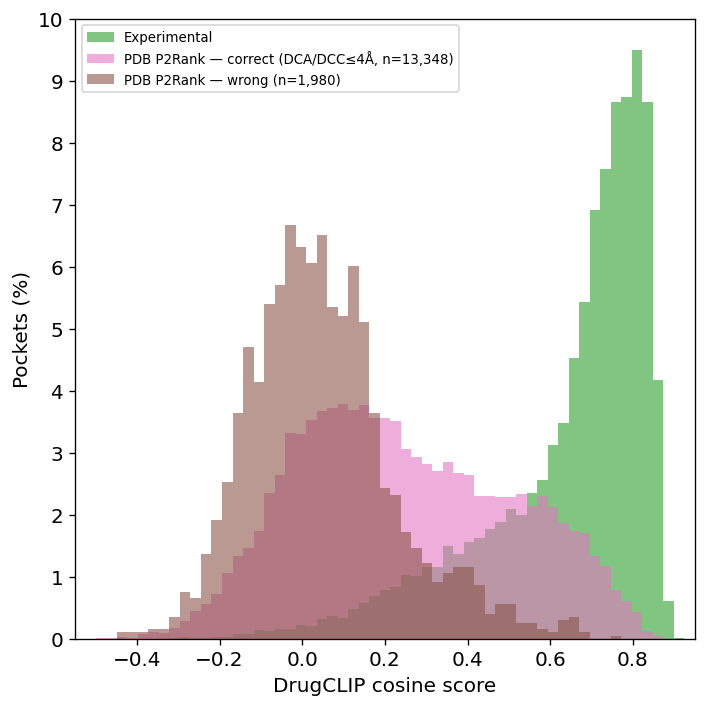

In [4]:
plot_score_distribution(CONDITIONS[0]);

PDB P2Rank: best vs worst DCA bin (n=15,328 pooled)


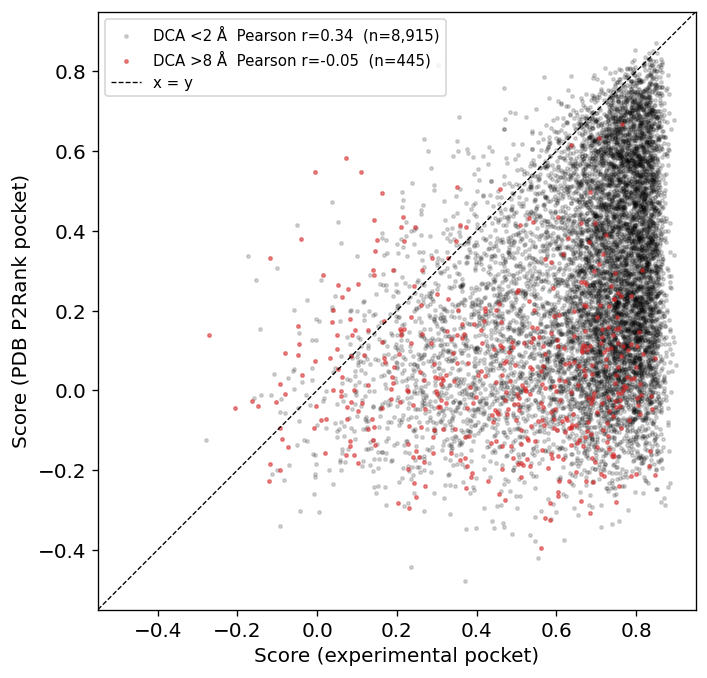

In [5]:
plot_best_worst_scatter(CONDITIONS[0]);

PDB P2Rank: pocket similarity vs DCA — log scale (n=15,328)
Spearman r = -0.331, p = 0.00e+00


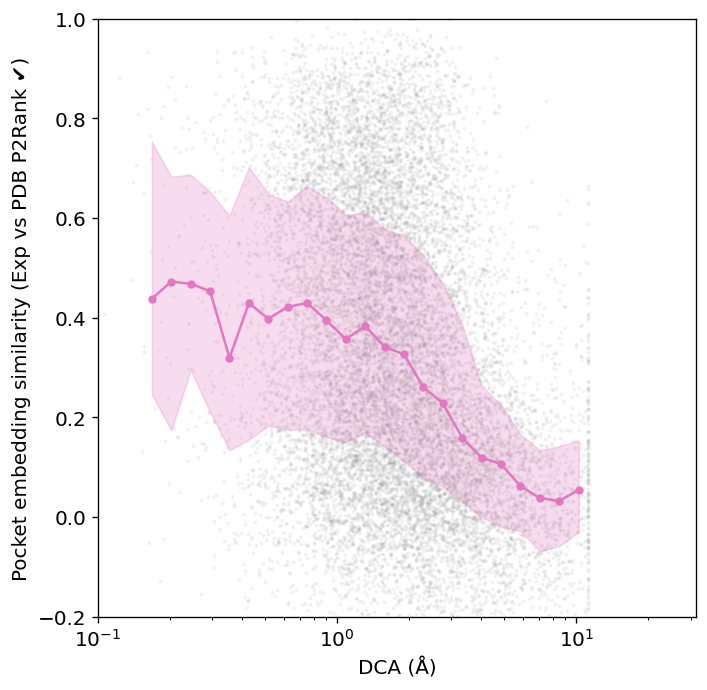

In [6]:
plot_pp_vs_metric(CONDITIONS[0], 'dca');

PDB P2Rank: pocket similarity vs DCA — linear 0-10 Å (n=15,328)
Spearman r = -0.331, p = 0.00e+00


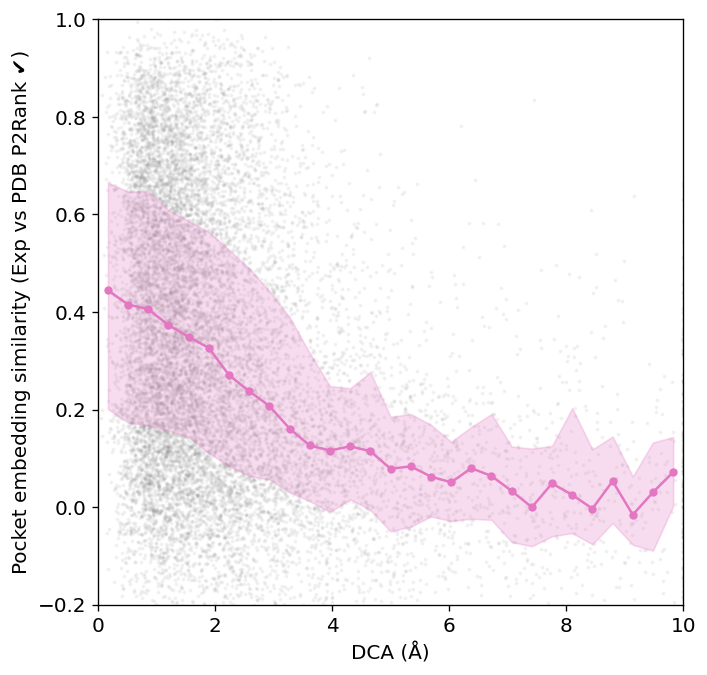

In [7]:
plot_pp_vs_metric(CONDITIONS[0], 'dca', log_x=False);

PDB P2Rank: pocket similarity vs DCC — log scale (n=15,328)
Spearman r = -0.619, p = 0.00e+00


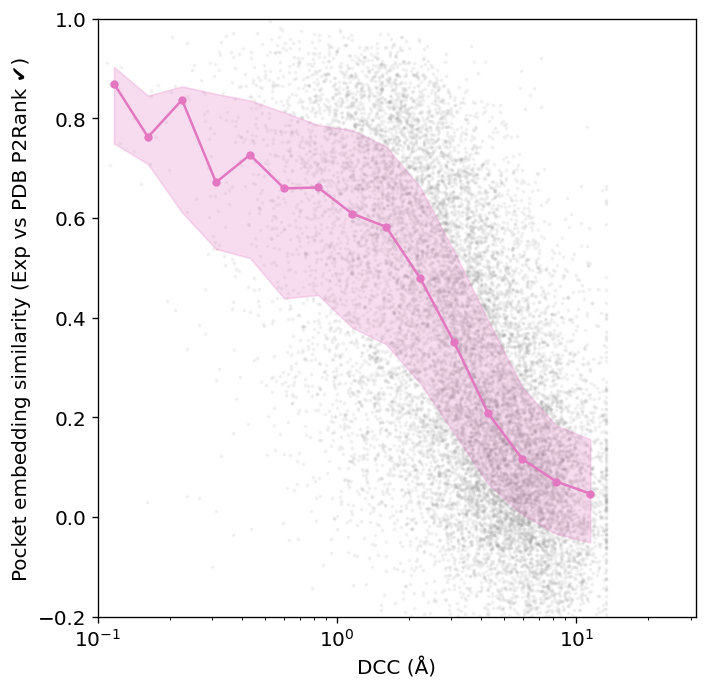

In [8]:
plot_pp_vs_metric(CONDITIONS[0], 'dcc');

PDB P2Rank: pocket similarity vs DCC — linear 0-10 Å (n=15,328)
Spearman r = -0.619, p = 0.00e+00


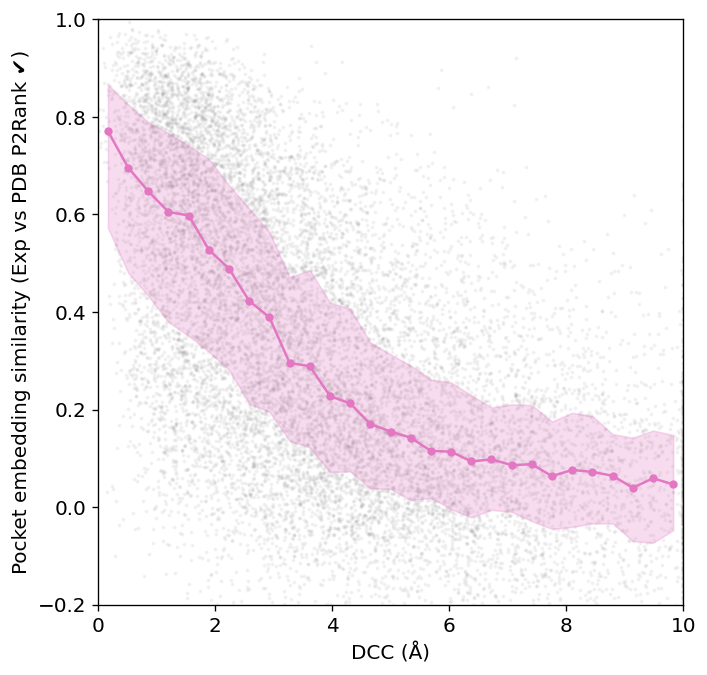

In [9]:
plot_pp_vs_metric(CONDITIONS[0], 'dcc', log_x=False);

PDB P2Rank: pocket similarity vs Residue Intersection over Union (n=15,328)
Spearman r = 0.693, p = 0.00e+00


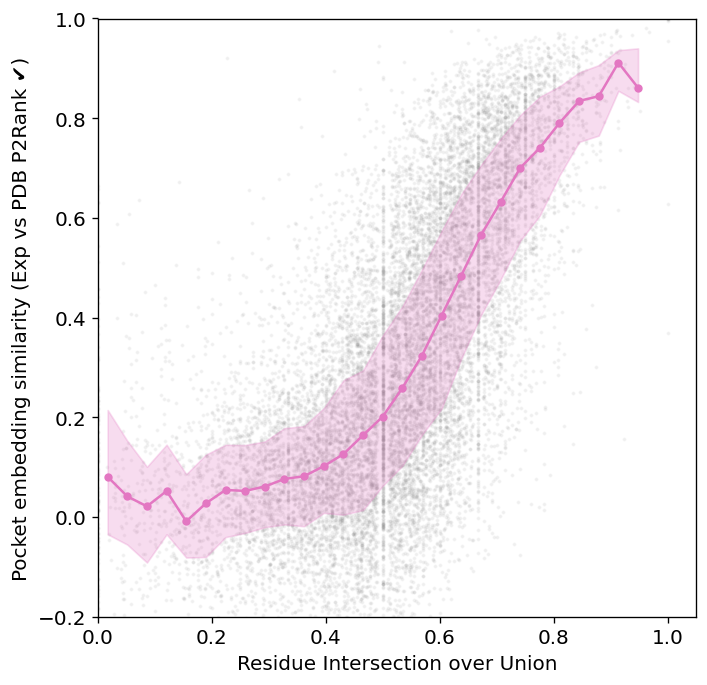

In [10]:
plot_pp_vs_metric(CONDITIONS[0], 'iou');

PDB P2Rank: pocket similarity vs Residue overlap (recall) (n=15,328)
Spearman r = 0.090, p = 8.39e-29


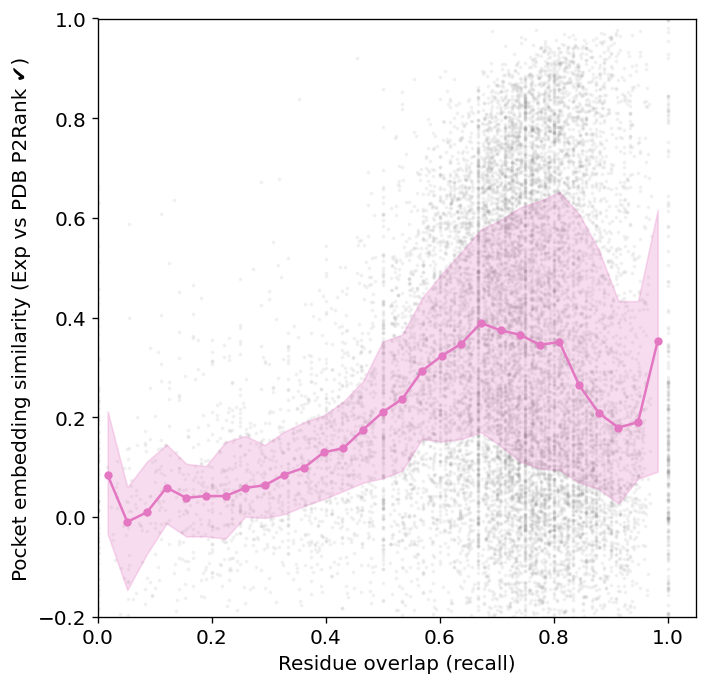

In [11]:
plot_pp_vs_metric(CONDITIONS[0], 'recall');

PDB P2Rank: pocket similarity vs score drop (n=15,328)
Spearman r = 0.713, p = 0.00e+00


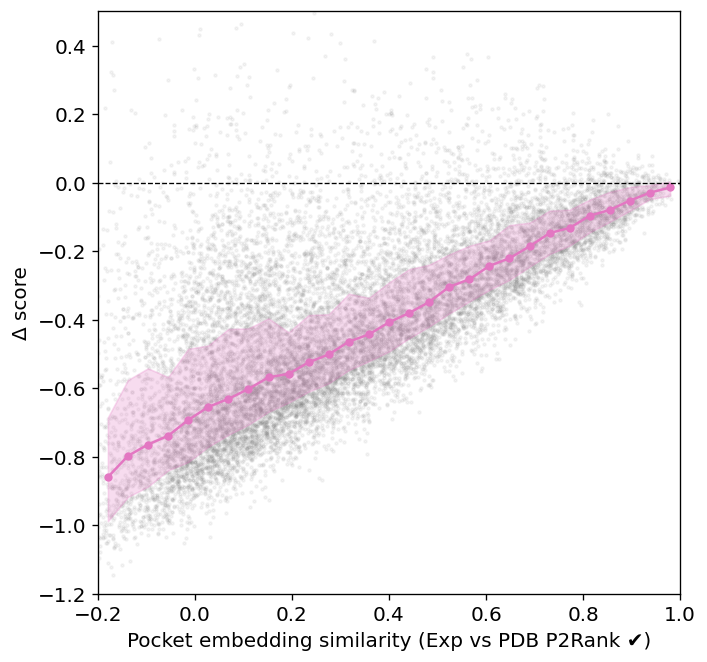

In [12]:
plot_pp_vs_delta(CONDITIONS[0]);

## AFDB P2Rank

DCA/DCC from nb38; IoU/recall recomputed in nb49 §2b (nb38 itself never saved them) from P2Rank's
raw predicted residues, the cached PDB↔AFDB alignment map, and the same 6 Å true-pocket residue
definition used everywhere else in this project.

AFDB P2Rank: score distribution (n=9,831)


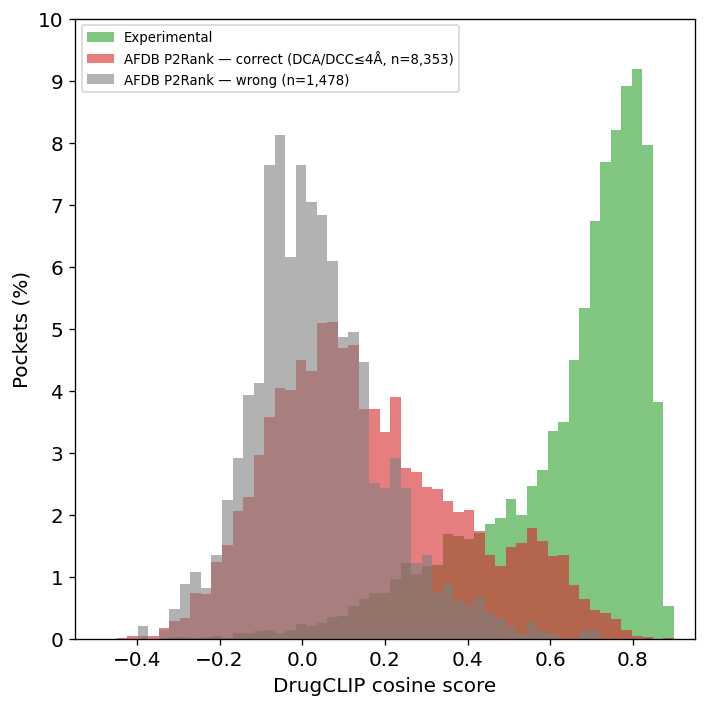

In [13]:
plot_score_distribution(CONDITIONS[1]);

AFDB P2Rank: best vs worst DCA bin (n=9,831 pooled)


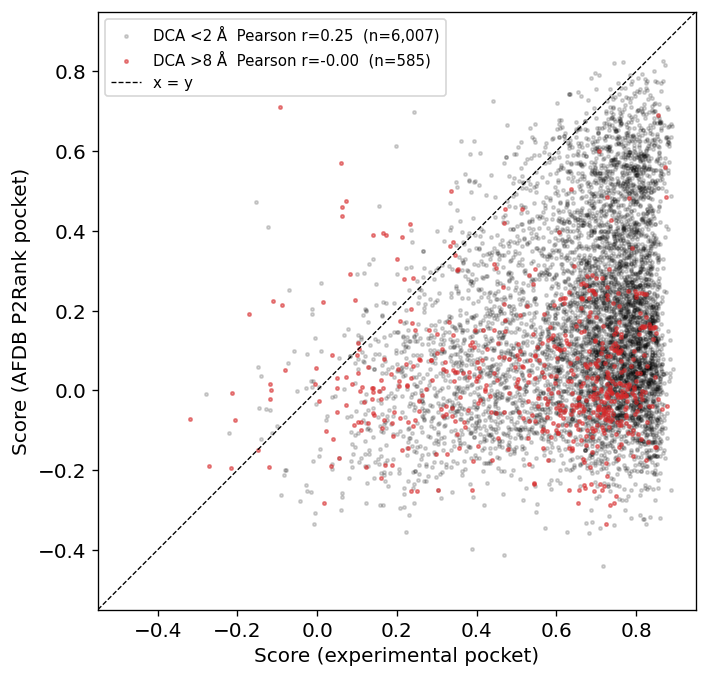

In [14]:
plot_best_worst_scatter(CONDITIONS[1]);

AFDB P2Rank: pocket similarity vs DCA — log scale (n=9,831)
Spearman r = -0.269, p = 8.03e-163


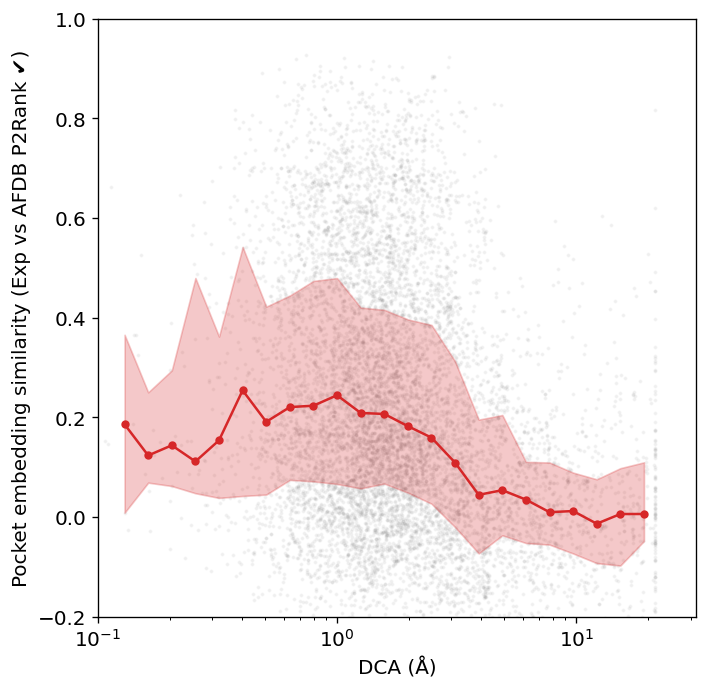

In [15]:
plot_pp_vs_metric(CONDITIONS[1], 'dca');

AFDB P2Rank: pocket similarity vs DCA — linear 0-10 Å (n=9,831)
Spearman r = -0.269, p = 8.03e-163


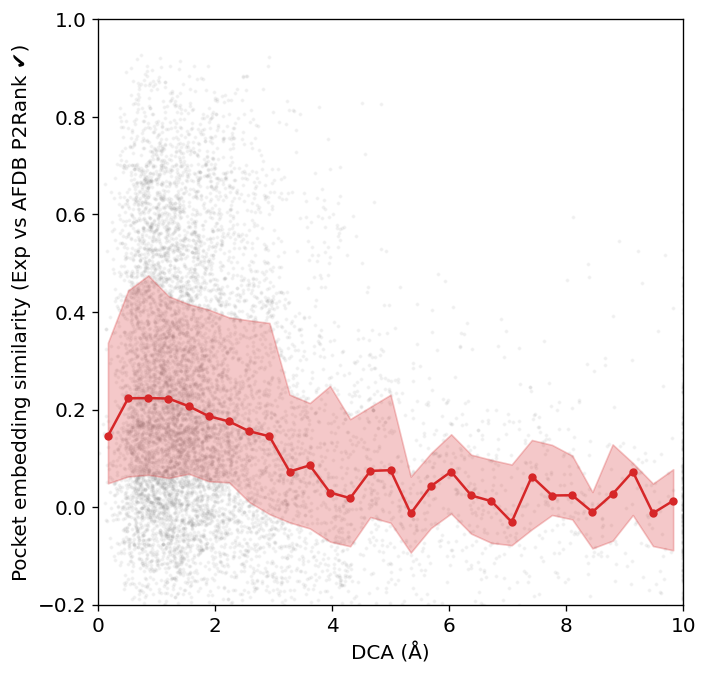

In [16]:
plot_pp_vs_metric(CONDITIONS[1], 'dca', log_x=False);

AFDB P2Rank: pocket similarity vs DCC — log scale (n=9,831)
Spearman r = -0.485, p = 0.00e+00


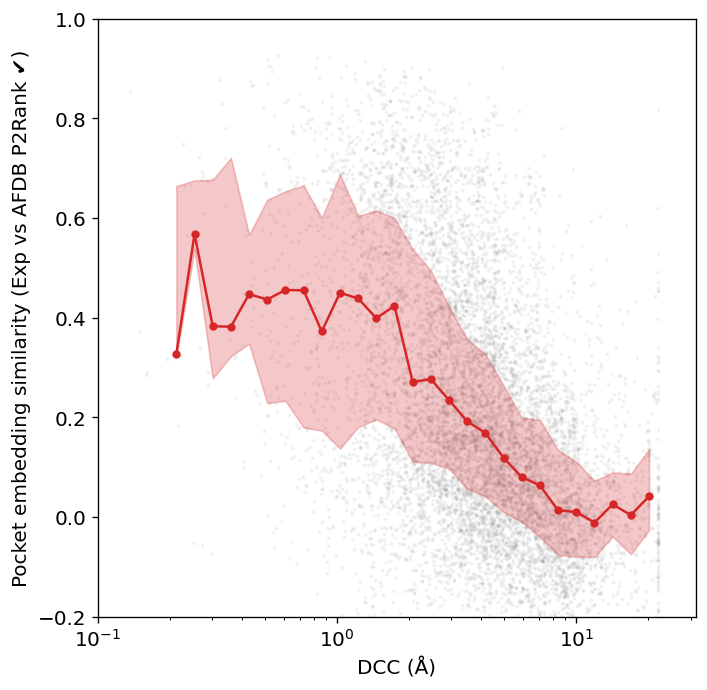

In [17]:
plot_pp_vs_metric(CONDITIONS[1], 'dcc');

AFDB P2Rank: pocket similarity vs DCC — linear 0-10 Å (n=9,831)
Spearman r = -0.485, p = 0.00e+00


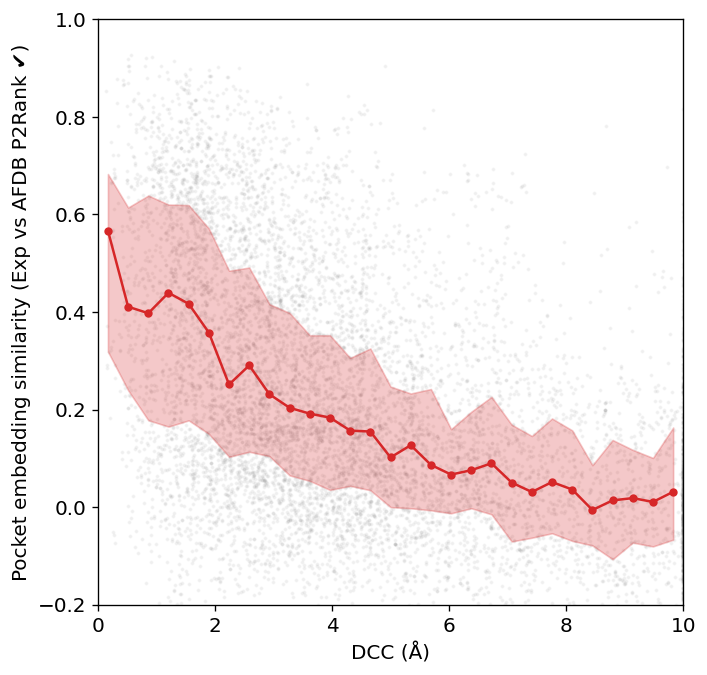

In [18]:
plot_pp_vs_metric(CONDITIONS[1], 'dcc', log_x=False);

AFDB P2Rank: pocket similarity vs Residue Intersection over Union (n=9,815)
Spearman r = 0.591, p = 0.00e+00


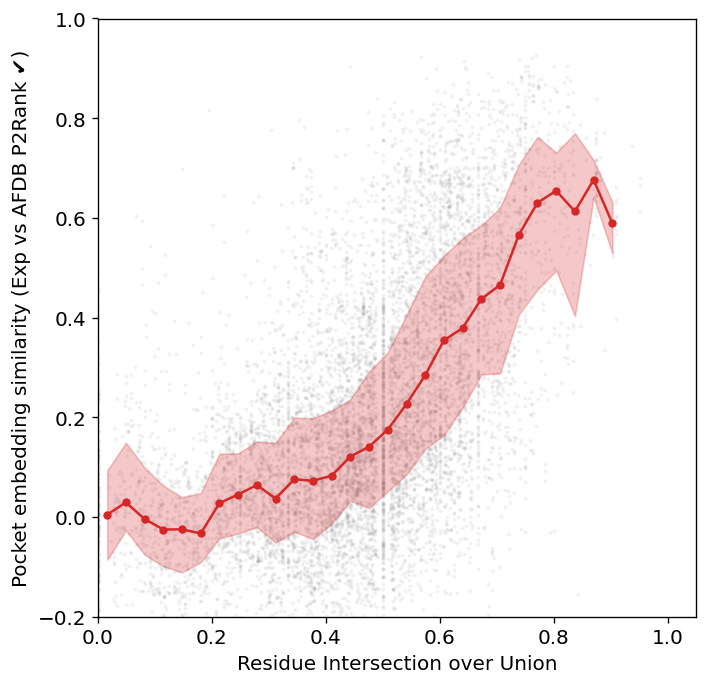

In [19]:
plot_pp_vs_metric(CONDITIONS[1], 'iou');

AFDB P2Rank: pocket similarity vs Residue overlap (recall) (n=9,815)
Spearman r = 0.438, p = 0.00e+00


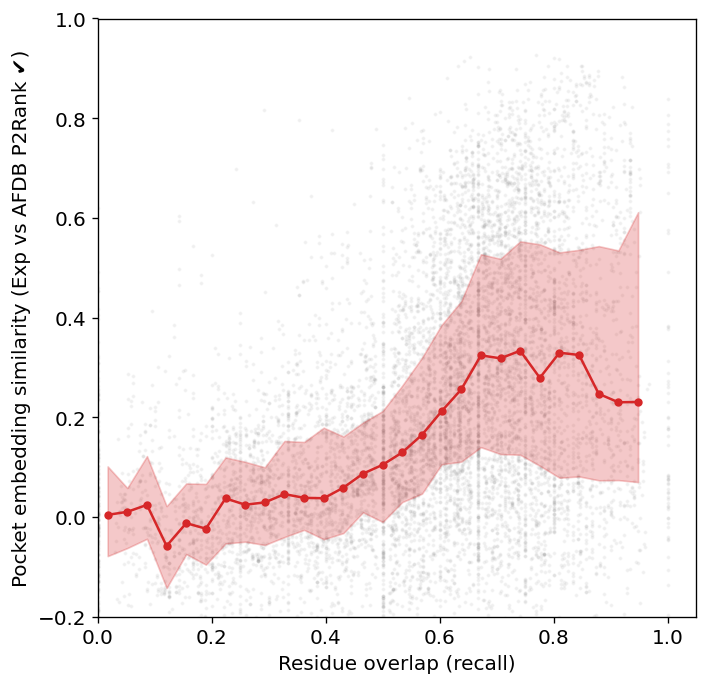

In [20]:
plot_pp_vs_metric(CONDITIONS[1], 'recall');

AFDB P2Rank: pocket similarity vs score drop (n=9,831)
Spearman r = 0.673, p = 0.00e+00


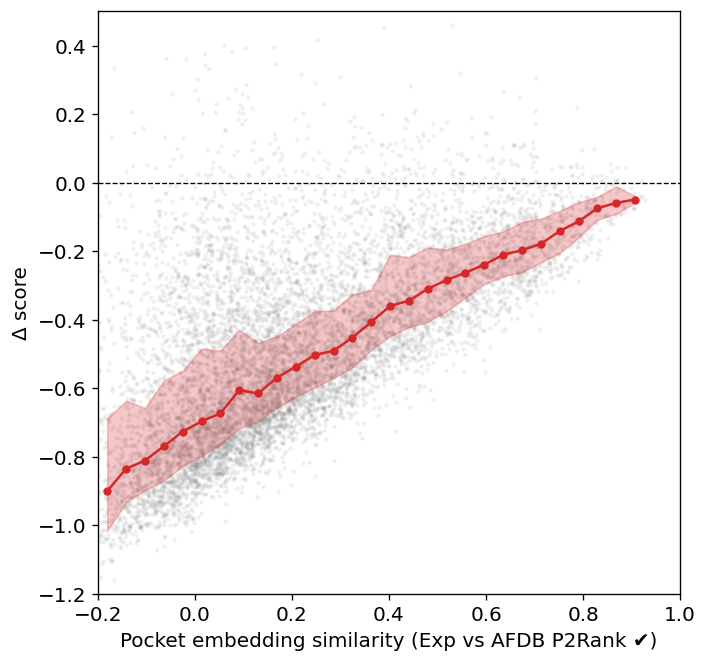

In [21]:
plot_pp_vs_delta(CONDITIONS[1]);

## Patches

Score distribution only — no DCA/DCC exists for a random patch, and there's no "best vs worst"
split to draw (nothing to rank a random patch by).

Patches: score distribution (n=15,640)


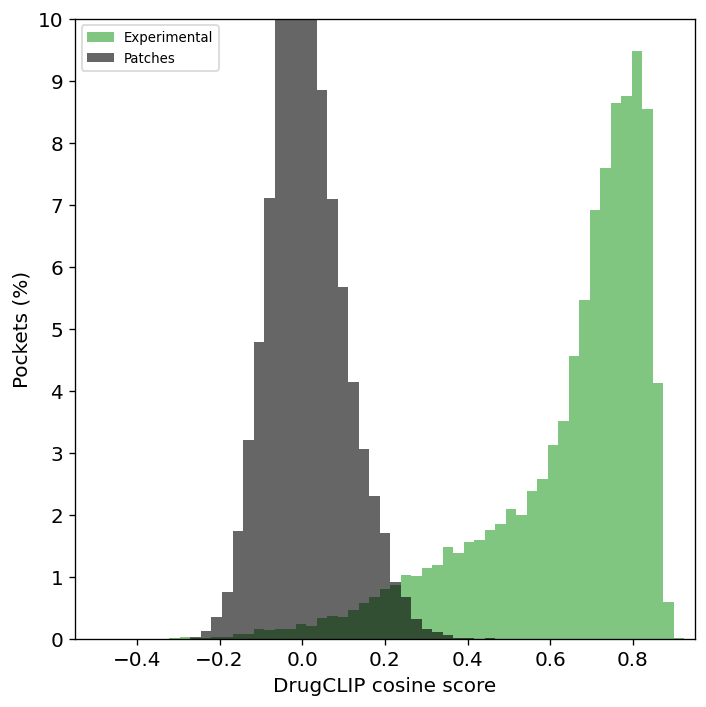

In [22]:
plot_score_distribution(CONDITIONS[2]);

## 5. Which metric actually predicts the score drop best?

DCA (distance from predicted pocket centre to nearest true-ligand atom) was used for every plot
above because it's the metric both conditions have in common. Both conditions now have all four:
DCA, **DCC** (predicted-centre to true-pocket-centroid distance), **IoU** and **recall**
(residue-level overlap with the true pocket) — PDB P2Rank's from nb35, AFDB P2Rank's recomputed in
nb49 §2b. Spearman r against `delta_score` for every metric, both conditions:

In [23]:
metric_cols = {
    'PDB P2Rank':  ['dca', 'dcc', 'iou', 'recall'],
    'AFDB P2Rank': ['dca', 'dcc', 'iou', 'recall'],
}
rows = []
for c in CONDITIONS[:2]:
    df = c['df']
    for col in metric_cols[c['name']]:
        sub = df.dropna(subset=[col, 'delta_score'])
        r, p = stats.spearmanr(sub[col], sub['delta_score'])
        rows.append({'condition': c['name'], 'metric': col, 'n': len(sub),
                     'spearman_r': round(r, 4), 'p_value': f'{p:.2e}'})
metric_tbl = pd.DataFrame(rows).set_index(['condition', 'metric'])
print(metric_tbl.to_string())
metric_tbl

                        n  spearman_r    p_value
condition   metric                              
PDB P2Rank  dca     15328     -0.1333   1.07e-61
            dcc     15328     -0.3963   0.00e+00
            iou     15328      0.4389   0.00e+00
            recall  15328      0.1568   6.09e-85
AFDB P2Rank dca      9831     -0.0676   1.90e-11
            dcc      9831     -0.2818  7.90e-179
            iou      9815      0.3594  5.24e-297
            recall   9815      0.3810   0.00e+00


n  spearman_r    p_value
condition   metric                              
PDB P2Rank  dca     15328     -0.1333   1.07e-61
            dcc     15328     -0.3963   0.00e+00
            iou     15328      0.4389   0.00e+00
            recall  15328      0.1568   6.09e-85
AFDB P2Rank dca      9831     -0.0676   1.90e-11
            dcc      9831     -0.2818  7.90e-179
            iou      9815      0.3594  5.24e-297
            recall   9815      0.3810   0.00e+00

Which residue/distance metric tracks the score drop best?


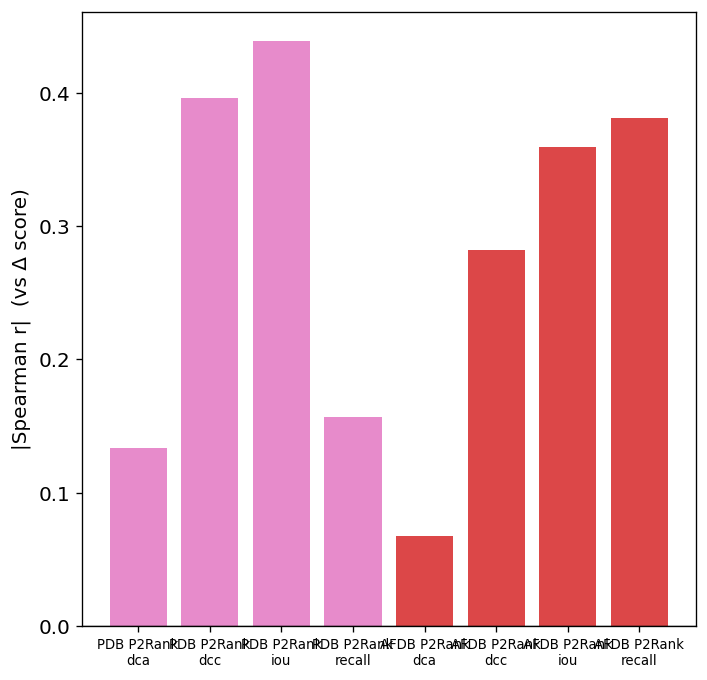

In [24]:
print('Which residue/distance metric tracks the score drop best?')
fig, ax = plt.subplots(figsize=(6, 6))
x_labels = [f'{c}\n{m}' for c, m in metric_tbl.index]
colors = [CONDITIONS[0]['color'] if c == 'PDB P2Rank' else CONDITIONS[1]['color']
          for c, _ in metric_tbl.index]
ax.bar(range(len(metric_tbl)), metric_tbl['spearman_r'].abs(), color=colors, alpha=0.85)
ax.set_xticks(range(len(metric_tbl)))
ax.set_xticklabels(x_labels, fontsize=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('|Spearman r|  (vs Δ score)')
fig.tight_layout()
square(fig)
save_fig(fig, 'metric_comparison_bar', True, 600);